In [1]:
from database.adatabase import ADatabase
import pandas as pd
from modeler.modeler import Modeler as m
from CFA.cfa import CFA as cfa
import matplotlib.pyplot as plt
from processor.processor import Processor as processor
from xgboost.sklearn import XGBRegressor
from tqdm import tqdm
import warnings
warnings.simplefilter(action="ignore")
import pickle
from datetime import datetime, timedelta, timezone

In [2]:
db = ADatabase("algo")
market = ADatabase("market")
fed = ADatabase("fed")
market.connect()
sp500 = market.retrieve("sp500")
market.disconnect()

In [3]:
holding_period = 65
tickers = sp500["ticker"].values
factors = ["assets","liabilities","stockholdersequity","adjclose"]
positions = len(sp500["GICS Sector"].unique())
training_year = 2020
training_years = 4

In [4]:
market.connect()
model = XGBRegressor(booster="gbtree",objective ='reg:squarederror', colsample_bytree = 0.3, learning_rate = 0.1,
                        max_depth = 5, alpha = 10, n_estimators = 100,  verbosity=0,refit=False)
for ticker in tqdm(tickers,desc="model_prep"):
    try:
        cik = sp500[sp500["ticker"]==ticker]["CIK"].item()
        ticker_prices = processor.column_date_processing(market.query("prices",{"ticker":ticker}))
        filings = market.query("filings",{"cik":cik})
        ticker_prices.sort_values("date",inplace=True)
        ticker_prices = processor.merge(ticker_prices,filings,["year","quarter"]).ffill()
        # for days in [5,10,20,60,100]:
        #     ticker_prices[f"rolling_{days}"] = ticker_prices["adjclose"].rolling(window=days).mean() 
        ticker_prices["y"] = ticker_prices["adjclose"].shift(-holding_period)
        model_data = ticker_prices[(ticker_prices["year"]<=training_year) & (ticker_prices["year"]>=training_year-training_years)].dropna().reset_index(drop=True)
        model.fit(model_data[factors],model_data["y"])
    except Exception as e:
        print(str(e))
        continue
market.disconnect()

model_prep:  13%|████████████████▏                                                                                                            | 65/503 [00:16<01:32,  4.73it/s]

'date'


model_prep:  16%|████████████████████▍                                                                                                        | 82/503 [00:21<01:26,  4.89it/s]

'date'
'year'


model_prep:  93%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎        | 468/503 [02:02<00:07,  4.45it/s]

'year'


model_prep: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 503/503 [02:10<00:00,  3.87it/s]

'date'


In [5]:
market.connect()
prices = []
for ticker in tqdm(tickers,desc="model_prep"):
    try:
        cik = sp500[sp500["ticker"]==ticker]["CIK"].item()
        ticker_prices = processor.column_date_processing(market.query("prices",{"ticker":ticker}))
        filings = market.query("filings",{"cik":cik})
        ticker_prices.sort_values("date",inplace=True)
        ticker_prices = processor.merge(ticker_prices,filings,["year","quarter"]).ffill()
        for days in [5,10,20,60,100]:
            ticker_prices[f"rolling_{days}"] = ticker_prices["adjclose"].rolling(window=days).mean() 
        simulation = ticker_prices[(ticker_prices["year"]>training_year)].reset_index(drop=True)
        simulation["prediction"] = model.predict(simulation[factors])
        simulation.sort_values("date",inplace=True)
        simulation["predicted_return"] = (simulation["prediction"] - simulation["adjclose"]) / simulation["adjclose"]
        simulation["signal"] = simulation["predicted_return"]
        simulation["buy_price"] = simulation["adjclose"].shift(-1)
        simulation["buy_date"] = simulation["date"].shift(-1)
        simulation["sell_price"] = simulation["adjclose"].shift(-holding_period)
        simulation["sell_date"] = simulation["date"].shift(-holding_period)
        prices.append(simulation)
    except Exception as e:
        print(str(e))
        continue
market.disconnect()

model_prep:  13%|████████████████▏                                                                                                            | 65/503 [00:11<01:01,  7.17it/s]

'date'


model_prep:  16%|████████████████████▍                                                                                                        | 82/503 [00:14<00:53,  7.84it/s]

'date'
'year'


model_prep:  93%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊        | 470/503 [01:25<00:04,  6.98it/s]

'year'


model_prep: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 503/503 [01:31<00:00,  5.48it/s]

'date'


In [6]:
sim = pd.concat(prices).reset_index(drop=True)
sim.sort_values("date",inplace=True)
sim = processor.merge(sim,sp500,on="ticker")
sim = cfa.cfa(sim,holding_period)

In [7]:
## backtest
trades = sim[sim["weekday"]==4]
trades = trades[trades["direction"]==1]
trades = trades[trades["week"] % int(holding_period/5) == 0]
trades = trades.sort_values("abs",ascending=False).groupby(["date","GICS Sector"]).first().reset_index()

In [8]:
trades = processor.column_date_processing(trades[["date","abs","direction","ticker","GICS Sector","adjclose","return"]])

In [9]:
portfolio = trades[["date","return"]].groupby("date").sum().reset_index()
portfolio.sort_values("date",inplace=True)
portfolio = portfolio[portfolio["date"]<portfolio["date"].max()]
portfolio["return"] = portfolio["return"] + 1
portfolio["cr"] = portfolio["return"].cumprod()

In [10]:
fed.connect()
bench = fed.retrieve("sp500")
fed.disconnect()
bench["date"] = pd.to_datetime(bench["date"],utc=True)
bench["value"] = [float(x) for x in bench["value"]]
portfolio = processor.column_date_processing(portfolio)
portfolio = processor.merge(portfolio,bench,on="date")
portfolio.dropna(inplace=True)
portfolio["bcr"] = (portfolio["value"] - portfolio["value"].iloc[0]) / portfolio["value"].iloc[0] + 1

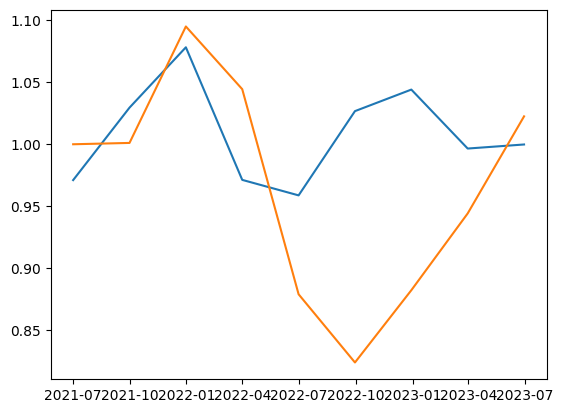

In [11]:
plt.plot(portfolio["date"].values,portfolio["cr"].values)
plt.plot(portfolio["date"].values,portfolio["bcr"].values)
plt.show()

In [12]:
recommendations = trades.tail(positions)

In [13]:
recommendations

,date,abs,direction,ticker,gics sector,adjclose,return,year,quarter,month,week,weekday
46,2023-06-30 00:00:00+00:00,0.909143,1.0,KMI,Energy,16.655800,-0.004546,2023,2,6,26,4
47,2023-06-30 00:00:00+00:00,0.910650,1.0,CFG,Financials,25.279337,-0.000998,2023,2,6,26,4
48,2023-06-30 00:00:00+00:00,0.404981,1.0,INTC,Information Technology,33.212075,0.006462,2023,2,6,26,4
49,2023-09-29 00:00:00+00:00,0.083532,1.0,CMCSA,Communication Services,44.046022,-0.049279,2023,3,9,39,4
50,2023-09-29 00:00:00+00:00,0.105886,1.0,BBWI,Consumer Discretionary,33.576898,-0.036299,2023,3,9,39,4
51,2023-09-29 00:00:00+00:00,0.060458,1.0,CAG,Consumer Staples,27.068847,-0.023169,2023,3,9,39,4
52,2023-09-29 00:00:00+00:00,0.081389,1.0,MRO,Energy,26.635550,-0.022067,2023,3,9,39,4
53,2023-09-29 00:00:00+00:00,0.198635,1.0,WFC,Financials,40.510000,-0.045645,2023,3,9,39,4
54,2023-09-29 00:00:00+00:00,0.385454,1.0,LUV,Industrials,27.070000,-0.023172,2023,3,9,39,4
55,2023-09-29 00:00:00+00:00,1.429984,1.0,AMCR,Materials,9.037736,0.111978,2023,3,9,39,4


In [14]:
db.connect()
db.drop('portfolios')
db.drop('trades')
db.drop('recommendations')
db.store("portfolio",portfolio)
db.store("trades",trades)
db.store("recommendations",recommendations)
db.disconnect()